In [1]:
import mdtraj as md
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
output_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles'
ref_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/pdbs'

In [3]:
def extract_ensemble(output_path, pdb_id):
    loss_csv=os.path.join(output_path, pdb_id, 'saved_structures.csv')
    loss_pd=pd.read_csv(loss_csv)
    loss_pd=loss_pd[~loss_pd['full_path'].str.contains('best')]
    loss_pd=loss_pd.sort_values(by='loss').reset_index(drop=True).head(50)
    return loss_pd

In [4]:
df=extract_ensemble(output_path,'1AEL-12_A')

In [5]:
def calc_Heli(t,length):
    dssp = md.compute_dssp(t)
    dssp_count = np.zeros((1, length))
    for j in range(t.n_residues):
            if dssp[0,j] in 'H':
                dssp_count[0,j] += 1
    summary = dssp_count.sum(axis=1)
    return(summary[0]/length)

def calc_Beta(t,length):
    dssp = md.compute_dssp(t)
    dssp_count = np.zeros((1, t.n_residues))
    for j in range(t.n_residues):
        if dssp[0,j] in 'E':
            dssp_count[0,j] += 1
    summary = dssp_count.sum(axis=1)
    return(summary[0]/length)

def calc_Rg(t):
    d = md.compute_rg(t)
    return(d[0])
    
def calc_Re(t):
    topology=t.topology
    rpology=topology.select_atom_indices(selection='alpha')
    d = md.compute_distances(t,[[rpology[0],rpology[-1]]])
    return(d[0][0])

In [6]:
def calc_contact(t):
    contact=md.compute_contacts(t, contacts='all', scheme='ca')
    # Use distance or the contact?
    contact_square=md.geometry.squareform(contact[0]<0.8,contact[1])
    #contact_square=md.geometry.squareform(contact[0],contact[1])
    return contact_square[0]

In [7]:
def analyze_conformation(confor_path):
    result_dic={}
    confor_frame = md.load(confor_path)
    length = confor_frame.n_residues
    confor_rg = calc_Rg(confor_frame)
    confor_re = calc_Re(confor_frame)
    confor_helicity =  calc_Heli(confor_frame,length)
    confor_beta = calc_Beta(confor_frame,length)
    confor_contact = calc_contact(confor_frame)
    result_dict={'seq_length':length,
                'rg':confor_rg,
                're':confor_re,
                'helicity':confor_helicity,
                'beta':confor_beta,}
    return result_dict, confor_contact, confor_frame

In [8]:
#df.loc[0,'full_path']

In [9]:
#analyze_conformation(df.loc[0,'full_path'])

In [10]:
def generate_rmsd_alphaSAXS(pdb_id,ref_path,output_path):
    results=[]
    contact_maps=[]
    ref_result, ref_contact, ref_t = analyze_conformation(os.path.join(ref_path,pdb_id+'.pdb'))
    ref_atom=ref_t.topology.select('name CA')
    generated_pdb_df = extract_ensemble(output_path,pdb_id)
    for index, single_pdb in generated_pdb_df.iterrows():
        saxs_loss = single_pdb['loss']
        result_dict, confor_contact, confor_frame = analyze_conformation(single_pdb['full_path'])
        contact_maps.append(confor_contact)
        confor_atom=confor_frame.topology.select('name CA')
        if len(confor_atom)!=len(ref_atom):
            print(pdb_id+' has the wrong length')
            print(test_frame, len(test_atom), ref_t, len(ref_atom))
            continue
        ca_rmsd=md.rmsd(confor_frame,ref_t,0,confor_atom,ref_atom)
        result_dict['rmsd']=ca_rmsd[0]*10
        result_dict['loss']=saxs_loss
        results.append(result_dict)
    averages = {
    key: np.mean([r[key] for r in results])
    for key in results[0].keys()
}
    best = min(results, key=lambda d: d['rmsd'])
    return averages,ref_result, contact_maps,ref_contact,results,best

In [11]:
averages,ref_result, contact_maps,ref_contact,results, best= generate_rmsd_alphaSAXS('2RS9-13_B',ref_path,output_path)

In [12]:
averages

{'seq_length': 121.0,
 'rg': 1.562715363690142,
 're': 2.2861478,
 'helicity': 0.6231404958677687,
 'beta': 0.0,
 'rmsd': 3.3605404675006865,
 'loss': 0.033646567200000005}

In [13]:
ref_result

{'seq_length': 121,
 'rg': 1.592974442925032,
 're': 4.033096,
 'helicity': 0.628099173553719,
 'beta': 0.0}

In [14]:
pdb_list=[ f[:-4] for f in os.listdir(ref_path) if f.endswith('.pdb')]

In [15]:
def build_protein_row(protein_id, averages, ref_result, best):
    metrics = ['seq_length', 'rg', 're', 'helicity', 'beta', 'rmsd','loss']
    row = {'protein_id': protein_id}
    for m in metrics:
        row[f'{m}_avg'] = averages.get(m, None)
        row[f'{m}_ref'] = ref_result.get(m, None)
        row[f'{m}_best'] = best.get(m, None)
    return row

In [16]:
rows=[]
results_dict={}
contact_dict={}
contact_ref={}
for i in pdb_list:
    try:
        averages,ref_result, contact_maps,ref_contact,results, best=generate_rmsd_alphaSAXS(i,ref_path,output_path)
        row = build_protein_row(i, averages, ref_result, best)
        results_dict[i]= results
        contact_dict[i]= contact_maps
        contact_ref[i]=ref_result
        rows.append(row) 
    except:
        print(f'{i} is not in the prediction dataset')

In [19]:
rows

[{'protein_id': '2K8R-1_A',
  'seq_length_avg': 133.0,
  'seq_length_ref': 133,
  'seq_length_best': 133,
  'rg_avg': 1.3737933046632111,
  'rg_ref': 1.3777686676285295,
  'rg_best': 1.3695647490598248,
  're_avg': 1.5367163,
  're_ref': 0.8620291,
  're_best': 1.4137695,
  'helicity_avg': 0.08375939849624058,
  'helicity_ref': 0.09022556390977443,
  'helicity_best': 0.09022556390977443,
  'beta_avg': 0.39609022556390977,
  'beta_ref': 0.3007518796992481,
  'beta_best': 0.40601503759398494,
  'rmsd_avg': 3.7132869362831116,
  'rmsd_ref': None,
  'rmsd_best': 3.5803166031837463,
  'loss_avg': 0.0151171524,
  'loss_ref': None,
  'loss_best': 0.01371296},
 {'protein_id': '1XSA-23_A',
  'seq_length_avg': 153.0,
  'seq_length_ref': 153,
  'seq_length_best': 153,
  'rg_avg': 1.4823223659034523,
  'rg_ref': 1.4687494692987917,
  'rg_best': 1.4873055794681653,
  're_avg': 4.640028,
  're_ref': 4.452528,
  're_best': 5.152053,
  'helicity_avg': 0.06549019607843137,
  'helicity_ref': 0.261437908

In [21]:
df_rows_rmsd=pd.DataFrame(rows)[['protein_id','rmsd_best','rmsd_avg']]


In [27]:
df_mean= df_rows_rmsd[['rmsd_best','rmsd_avg']].mean().reset_index()

In [41]:
df_mean.columns=['Metrics','Value']
df_mean['Metrics']=['Best RMSD','Average RMSD']

In [42]:
import seaborn as sns

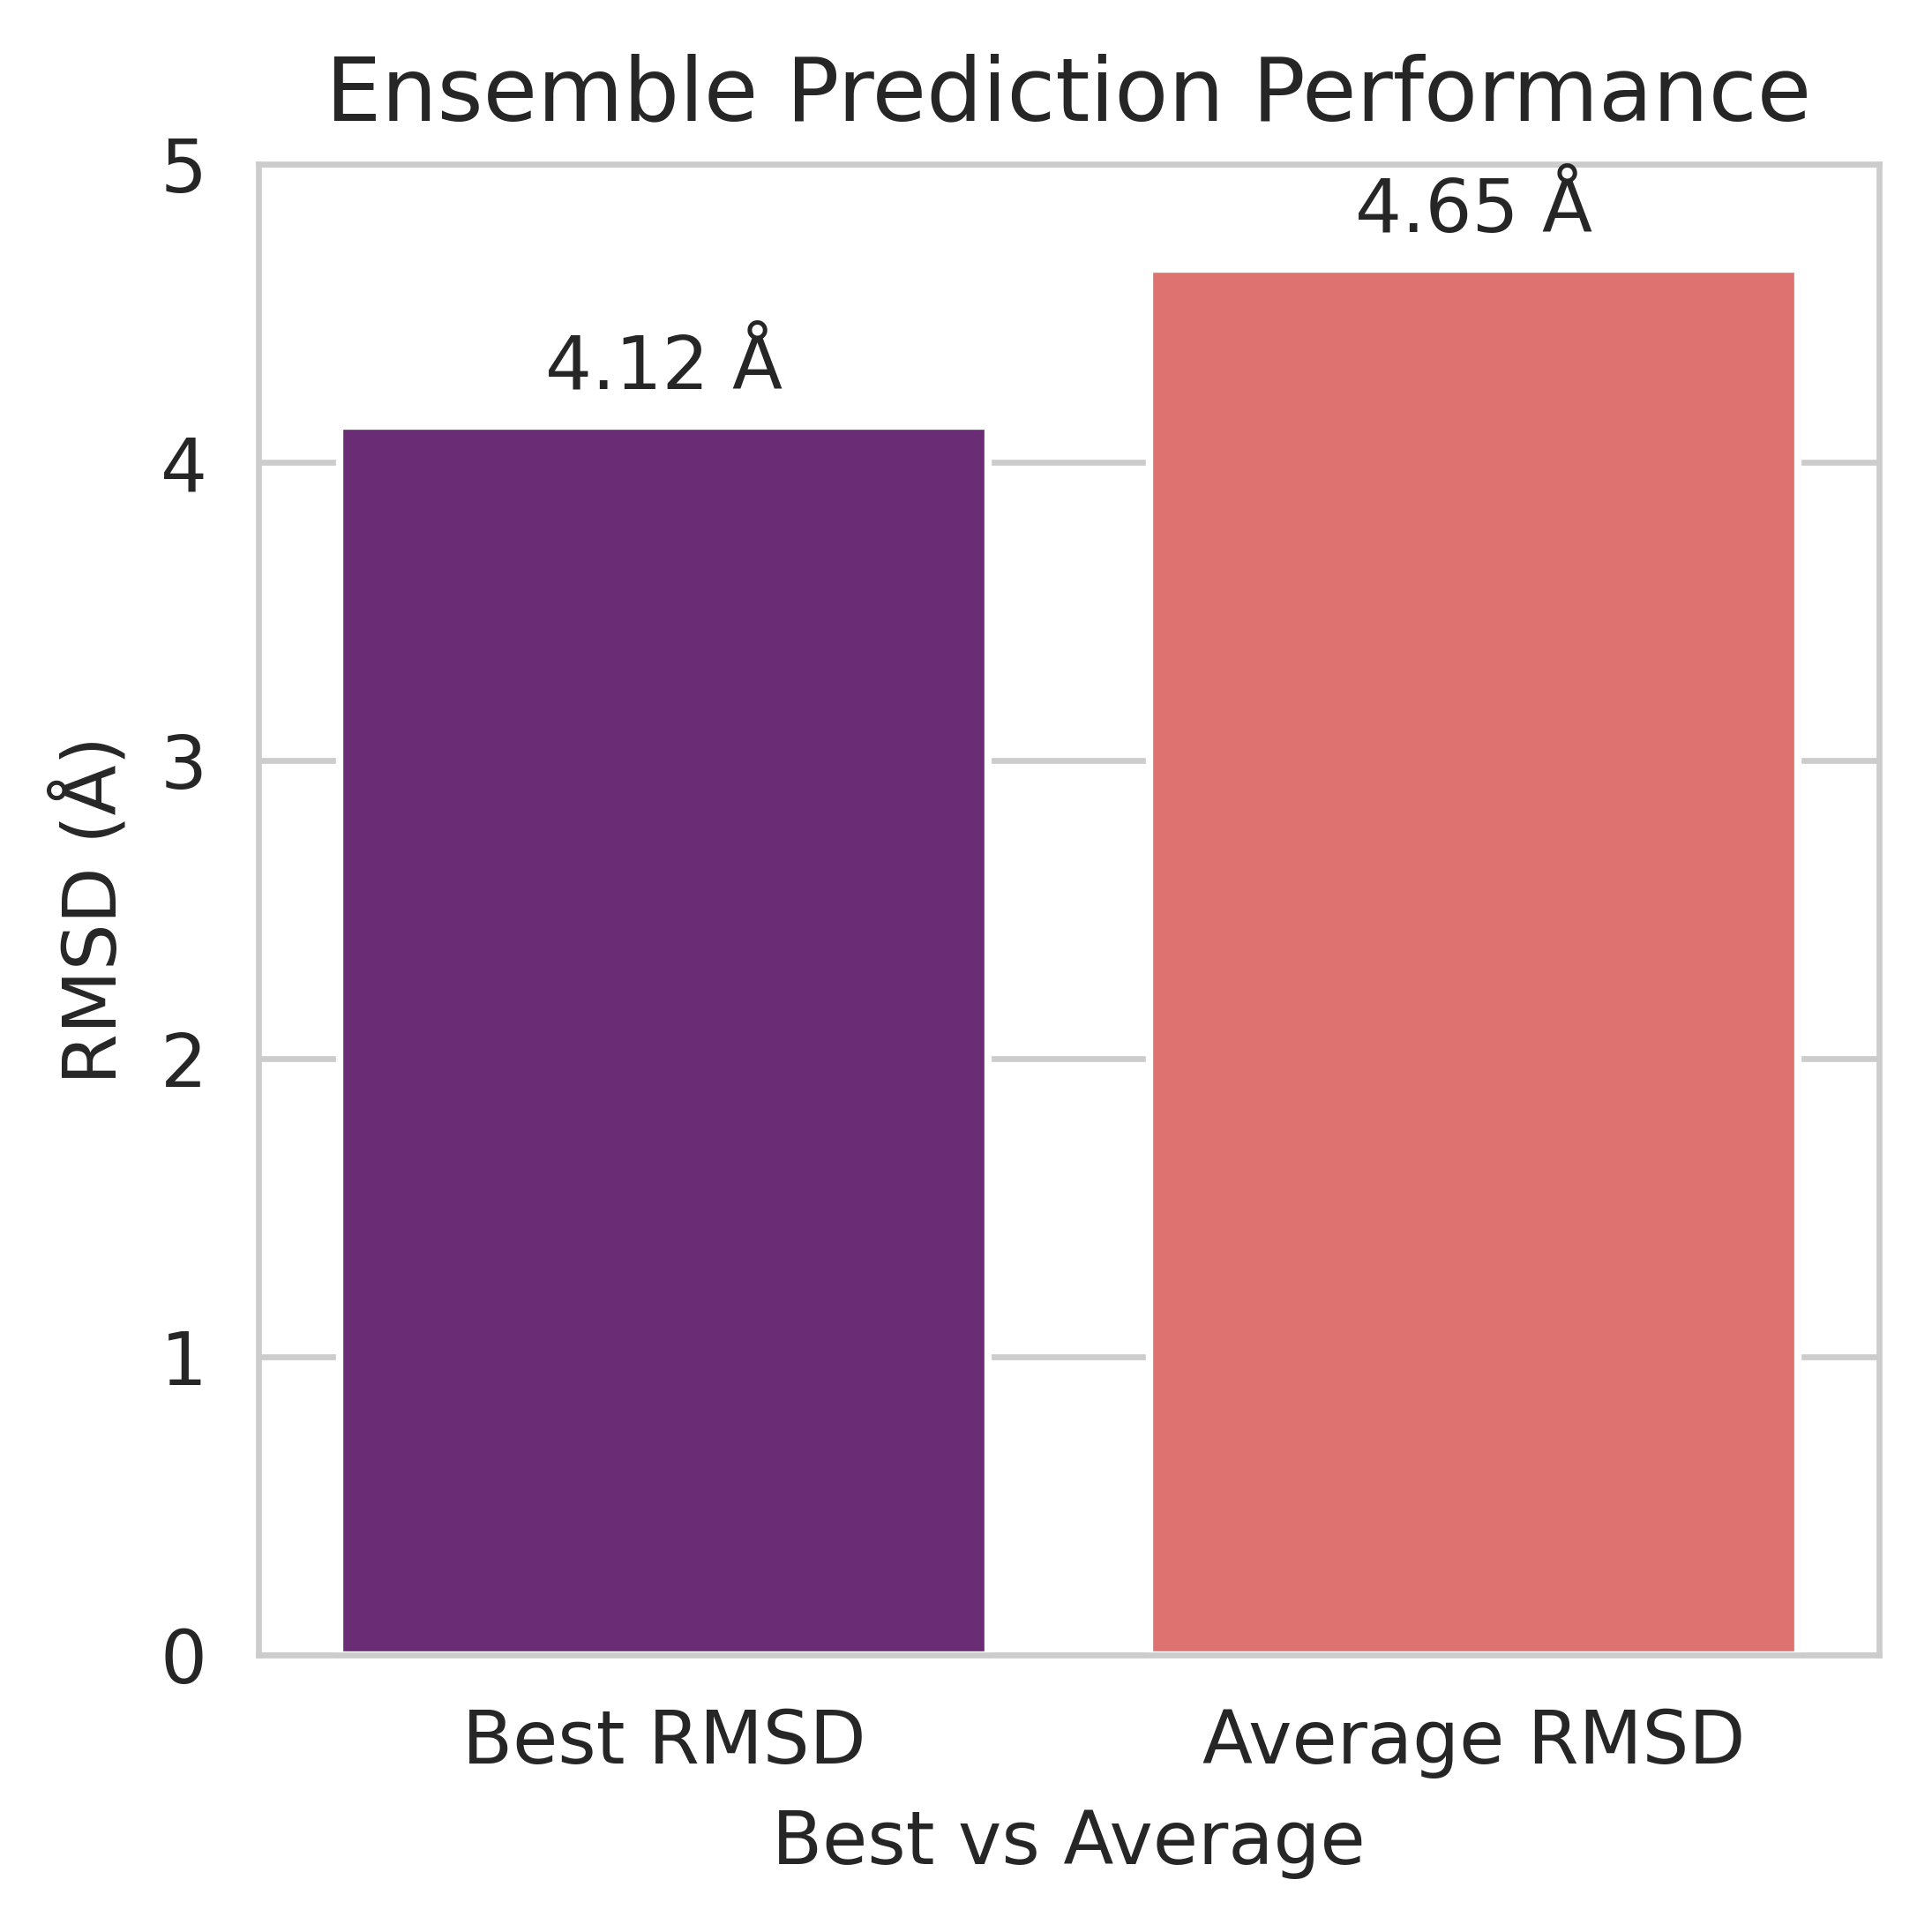

In [49]:
plt.figure(figsize=(3.75,3.75),dpi=600)
#sns.set_style('whitegrid')
ax = sns.barplot(data=df_mean, x='Metrics',y='Value',hue='Metrics',palette='magma',legend=None)
plt.hlines(4.55,-0.6,1.6,linestyles='--',color='red',label='AlphaSAXS Baseline')
plt.title('Ensemble Method Performance')
plt.ylabel('Accuracy RMSD vs Ground Truth (Å)')
#plt.xlabel('Best vs Average')
plt.ylim(0,5.5)
for containers in ax.containers:
    ax.bar_label(containers, fmt="%.2f Å",padding=3)
plt.tight_layout()
plt.legend(loc=2)
plt.savefig('Ensemble_average.png')

In [17]:
import pickle

save_data = {
    "rows": rows,
    "results_dict": results_dict,
    "contact_dict": contact_dict,
    "contact_ref": contact_ref
}

with open("protein_analysis.pkl", "wb") as f:
    pickle.dump(save_data, f)

In [18]:
'''
with open("protein_analysis.pkl", "rb") as f:
    loaded_data = pickle.load(f)

rows = loaded_data["rows"]
results_dict = loaded_data["results_dict"]
contact_dict = loaded_data["contact_dict"]
contact_ref = loaded_data["contact_ref"]
'''

'\nwith open("protein_analysis.pkl", "rb") as f:\n    loaded_data = pickle.load(f)\n\nrows = loaded_data["rows"]\nresults_dict = loaded_data["results_dict"]\ncontact_dict = loaded_data["contact_dict"]\ncontact_ref = loaded_data["contact_ref"]\n'

In [19]:
df_result = pd.DataFrame(rows)
print(df_result)

   protein_id  seq_length_avg  seq_length_ref  seq_length_best    rg_avg  \
0    2K8R-1_A           133.0             133              133  1.373793   
1   1XSA-23_A           153.0             153              153  1.482322   
2    1K2H-4_A            93.0              93               93  1.403140   
3   2D9E-12_A           121.0             121              121  1.526964   
4   1P7M-18_A           187.0             187              187  1.705712   
..        ...             ...             ...              ...       ...   
75   1LMZ-9_A           187.0             187              187  1.722596   
76  2LKD-18_A           178.0             178              178  1.589185   
77   2CJO-5_A            97.0              97               97  1.192787   
78  1MUT-11_A           129.0             129              129  1.428944   
79   1KRX-4_A           124.0             124              124  1.302956   

      rg_ref   rg_best    re_avg    re_ref   re_best  ...  helicity_best  \
0   1.37776

In [21]:
!pwd

/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/notebooks


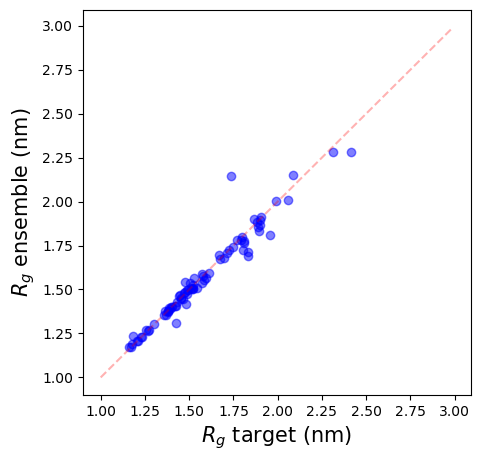

In [25]:
plt.figure(figsize=(5,5))
plt.scatter(df_result['rg_ref'],df_result['rg_avg'], alpha=0.5, color='blue')
plt.plot(np.arange(1,3,0.01),np.arange(1,3,0.01),'--',color='red',alpha=0.3)
plt.xlabel(r'$R_g$ target (nm)',fontsize=15)
plt.ylabel(r'$R_g$ ensemble (nm)',fontsize=15)
plt.savefig('./figures/Rg_ensemble.png', bbox_inches='tight')

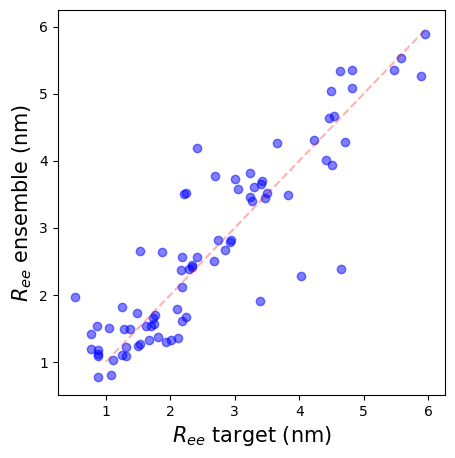

In [26]:
plt.figure(figsize=(5,5))
plt.scatter(df_result['re_ref'],df_result['re_avg'], alpha=0.5, color='blue')
plt.plot(np.arange(1,6,0.01),np.arange(1,6,0.01),'--',color='red',alpha=0.3)
plt.xlabel(r'$R_{ee}$ target (nm)',fontsize=15)
plt.ylabel(r'$R_{ee}$ ensemble (nm)',fontsize=15)
plt.savefig('./figures/Ree_ensemble.png', bbox_inches='tight')

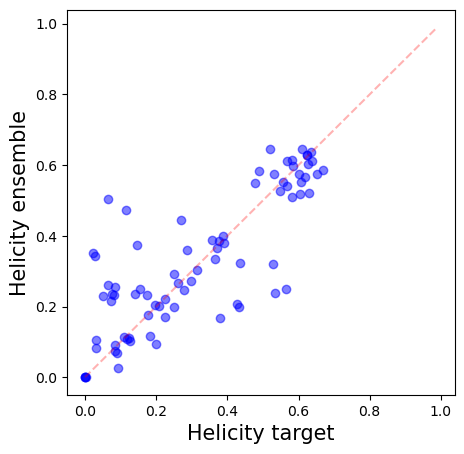

In [27]:
plt.figure(figsize=(5,5))
plt.scatter(df_result['helicity_avg'],df_result['helicity_ref'], alpha=0.5, color='blue')
plt.plot(np.arange(0,1,0.01),np.arange(0,1,0.01),'--',color='red',alpha=0.3)
plt.xlabel('Helicity target',fontsize=15)
plt.ylabel('Helicity ensemble',fontsize=15)
plt.savefig('./figures/helicity_ensemble.png', bbox_inches='tight')

Text(0, 0.5, 'Average $R_{ee}$ error (nm)')

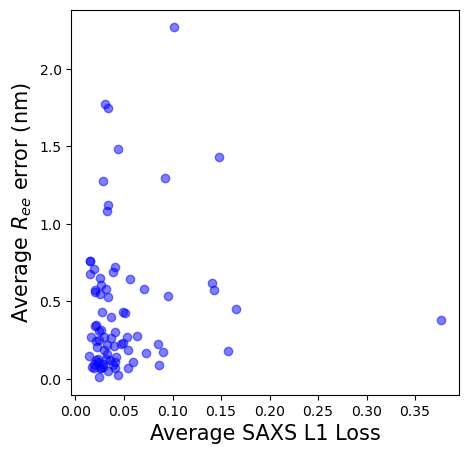

In [60]:
plt.figure(figsize=(5,5))
plt.scatter(df_result['loss_avg'],abs(df_result['re_avg']-df_result['re_ref']), alpha=0.5, color='blue')
plt.xlabel('Average SAXS L1 Loss',fontsize=15)
plt.ylabel(r'Average $R_{ee}$ error (nm)',fontsize=15)

Text(0, 0.5, 'Average $R_{g}$ error (nm)')

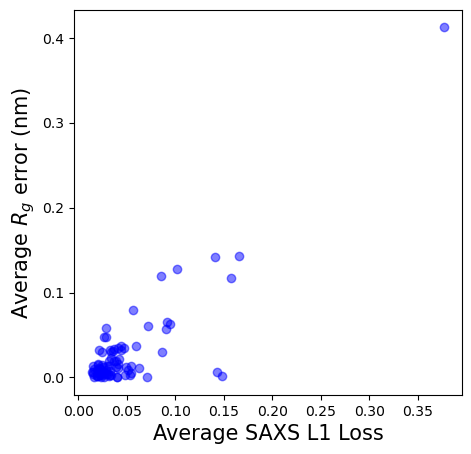

In [61]:
plt.figure(figsize=(5,5))
plt.scatter(df_result['loss_avg'], abs(df_result['rg_avg']-df_result['rg_ref']), alpha=0.5, color='blue')
plt.xlabel('Average SAXS L1 Loss',fontsize=15)
plt.ylabel(r'Average $R_{g}$ error (nm)',fontsize=15)

# Analysis for specific examples

In [45]:
def generate_rmsd_alphaSAXS_pair(pdb_id,ref_path,output_path,pair_id):
    results=[]
    contact_maps=[]
    ref_result, ref_contact, ref_t = analyze_conformation(os.path.join(ref_path,pdb_id+'.pdb'))
    ref_atom=ref_t.topology.select('name CA')
    ref_result_pair, ref_contact_pair, ref_t_pair = analyze_conformation(os.path.join(ref_path,pair_id+'.pdb'))
    ref_atom_pair=ref_t_pair.topology.select('name CA')
    generated_pdb_df = extract_ensemble(output_path,pdb_id)
    for index, single_pdb in generated_pdb_df.iterrows():
        saxs_loss = single_pdb['loss']
        result_dict, confor_contact, confor_frame = analyze_conformation(single_pdb['full_path'])
        contact_maps.append(confor_contact)
        confor_atom=confor_frame.topology.select('name CA')
        if len(confor_atom)!=len(ref_atom):
            print(pdb_id+' has the wrong length')
            print(test_frame, len(test_atom), ref_t, len(ref_atom))
            continue
        ca_rmsd=md.rmsd(confor_frame,ref_t,0,confor_atom,ref_atom)
        ca_rmsd_pair=md.rmsd(confor_frame,ref_t_pair,0,confor_atom,ref_atom_pair)
        result_dict['rmsd']=ca_rmsd[0]*10
        result_dict['rmsd_pair']=ca_rmsd_pair[0]*10
        result_dict['loss']=saxs_loss
        results.append(result_dict)
    averages = {
    key: np.mean([r[key] for r in results])
    for key in results[0].keys()
}
    best = min(results, key=lambda d: d['rmsd'])
    return averages,ref_result, contact_maps,ref_contact,results,best

In [46]:
pair_dict={}

In [47]:
averages,ref_result, contact_maps,ref_contact,results, best= generate_rmsd_alphaSAXS_pair('1JFJ-3_A',ref_path,output_path,'1JFK_A')
pair_dict['apo_ensemble']=contact_maps
pair_dict['apo_shape']=results
pair_dict['apo_ref']=ref_contact
pair_dict['apo_ref_shape']=ref_result

In [48]:
averages,ref_result, contact_maps,ref_contact,results, best= generate_rmsd_alphaSAXS_pair('1JFK_A',ref_path,output_path,'1JFJ-3_A')
pair_dict['holo_ensemble']=contact_maps
pair_dict['holo_shape']=results
pair_dict['holo_ref']=ref_contact
pair_dict['holo_ref_shape']=ref_result

In [25]:
def flatten_contact_map(cm):
    # Use upper triangle without diagonal
    return cm[np.triu_indices_from(cm, k=1)]

In [26]:
pair_dict['apo_ensemble_flatten'] = np.array([flatten_contact_map(cm) for cm in pair_dict['apo_ensemble']])
pair_dict['apo_ref_flatten'] = flatten_contact_map(pair_dict['apo_ref'])
pair_dict['holo_ensemble_flatten'] = np.array([flatten_contact_map(cm) for cm in pair_dict['holo_ensemble']])
pair_dict['holo_ref_flatten'] = flatten_contact_map(pair_dict['holo_ref'])

In [27]:
np.mean(pair_dict['holo_ref_flatten'])

0.03164627987880148

In [28]:
np.mean(pair_dict['holo_ensemble_flatten'][0])

0.03220738413197172

In [29]:
pair_dict['holo_ensemble_flatten'].shape

(50, 8911)

In [30]:
np.mean(pair_dict['apo_ref_flatten'])

0.03119739647626529

In [31]:
pair_dict['apo_ref_flatten'].shape

(8911,)

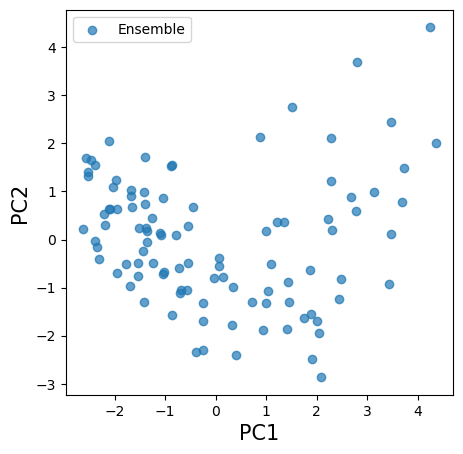

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(np.concatenate((pair_dict['apo_ensemble_flatten'],pair_dict['holo_ensemble_flatten'])))
# Plot ensemble + reference
plt.figure(figsize=(5,5))
plt.scatter(pca_result[:,0], pca_result[:,1], label='Ensemble', alpha=0.7)
apo_ref_proj = pca.transform(pair_dict['apo_ref_flatten'].reshape(1, -1))
#plt.scatter(apo_ref_proj[:,0], apo_ref_proj[:,1], color='red', label='Reference', marker='*', s=200)
holo_ref_proj = pca.transform(pair_dict['holo_ref_flatten'].reshape(1, -1))
#plt.scatter(holo_ref_proj[:,0], holo_ref_proj[:,1], color='green', label='Reference', marker='*', s=200)
plt.xlabel('PC1',fontsize=15)
plt.ylabel('PC2',fontsize=15)
plt.legend()
plt.show()

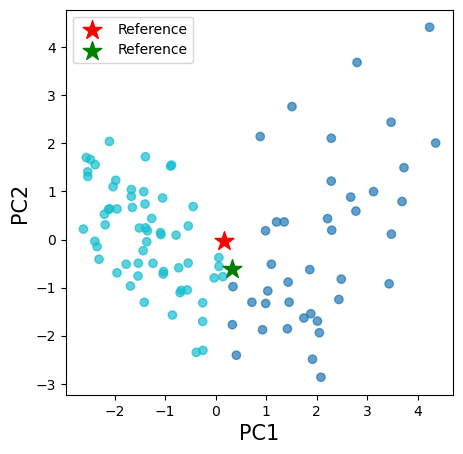

In [33]:
from sklearn.cluster import AgglomerativeClustering
plt.figure(figsize=(5,5))
clusters = AgglomerativeClustering(n_clusters=2) # adjust clusters as needed
labels = clusters.fit_predict(np.concatenate((pair_dict['apo_ensemble_flatten'],pair_dict['holo_ensemble_flatten'])))

scatter=plt.scatter(pca_result[:,0], pca_result[:,1], c=labels, cmap='tab10', alpha=0.7)
plt.scatter(apo_ref_proj[:,0], apo_ref_proj[:,1], color='red', label='Reference', marker='*', s=200)
plt.scatter(holo_ref_proj[:,0], holo_ref_proj[:,1], color='green', label='Reference', marker='*', s=200)
plt.xlabel('PC1',fontsize=15)
plt.ylabel('PC2',fontsize=15)
plt.legend()
plt.show()

In [34]:
pair_dict['holo_ref_flatten']

array([False, False,  True, ..., False, False, False])

In [35]:
pair_dict['holo_ensemble_flatten']

array([[False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False]])

In [36]:
from sklearn.metrics import jaccard_score

In [37]:
apo_true_index=[i for i,x in enumerate(pair_dict['apo_ref_flatten']) if x]

In [38]:
holo_true_index=[i for i,x in enumerate(pair_dict['holo_ref_flatten']) if x]

In [39]:
feature_set=np.array(list(set(apo_true_index + holo_true_index)), dtype=int)

In [40]:
def jaccard_ensemble(ensemble,ref,standard, index=[]):
    result=[]
    for i in ensemble:
        if index is not None and len(index) != 0:
            result.append(jaccard_score(ref[index],i[index]))
        else:
            result.append(jaccard_score(ref,i))
    return abs(result-standard)

In [41]:
standard= jaccard_score(pair_dict['holo_ref_flatten'][feature_set],pair_dict['apo_ref_flatten'][feature_set])

In [42]:
holo_holo=jaccard_ensemble(pair_dict['holo_ensemble_flatten'],pair_dict['holo_ref_flatten'],standard,feature_set)
holo_apo=jaccard_ensemble(pair_dict['holo_ensemble_flatten'],pair_dict['apo_ref_flatten'],standard,feature_set)
apo_holo=jaccard_ensemble(pair_dict['apo_ensemble_flatten'],pair_dict['holo_ref_flatten'],standard,feature_set)
apo_apo=jaccard_ensemble(pair_dict['apo_ensemble_flatten'],pair_dict['apo_ref_flatten'],standard,feature_set)

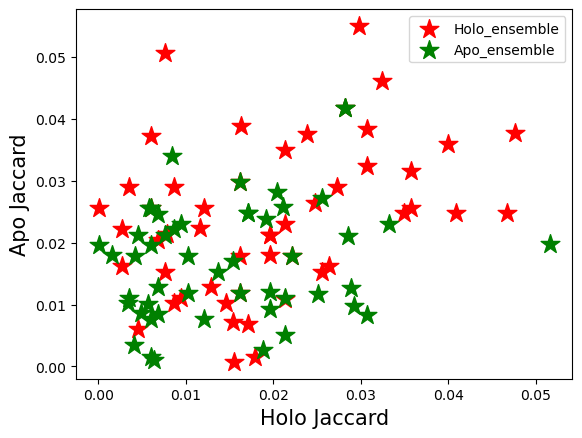

In [43]:
plt.scatter(holo_holo, holo_apo, color='red', label='Holo_ensemble', marker='*', s=200)
plt.scatter(apo_holo, apo_apo, color='green', label='Apo_ensemble', marker='*', s=200)
plt.xlabel('Holo Jaccard',fontsize=15)
plt.ylabel('Apo Jaccard',fontsize=15)

plt.legend()
plt.show()

In [50]:
def rmsd_ensemble(ensemble):
    result=[]
    result_pair=[]
    for i in ensemble:
            result.append(i['rmsd'])
            result_pair.append(i['rmsd_pair'])
    return result, result_pair

In [51]:
apo_apo_rmsd,apo_holo_rmsd=rmsd_ensemble(pair_dict['apo_shape'])

In [52]:
holo_holo_rmsd,holo_apo_rmsd=rmsd_ensemble(pair_dict['holo_shape'])

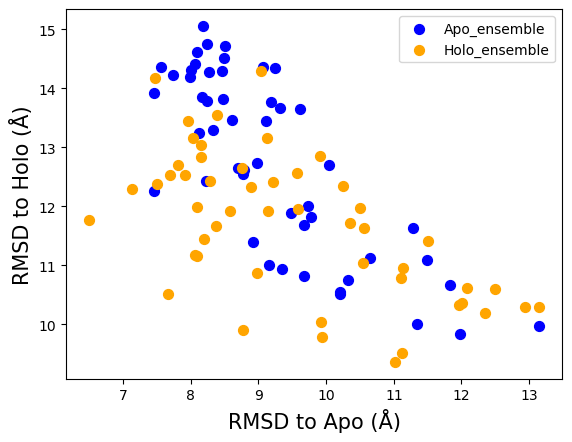

In [75]:
#plt.hist2d(apo_apo_rmsd+holo_apo_rmsd, apo_holo_rmsd+holo_holo_rmsd, bins=10)
plt.scatter(apo_apo_rmsd, apo_holo_rmsd, color='blue', label='Apo_ensemble', marker='.', s=200)
plt.scatter(holo_apo_rmsd, holo_holo_rmsd, color='orange', label='Holo_ensemble', marker='.', s=200)
plt.xlabel('RMSD to Apo (Å)',fontsize=15)
plt.ylabel('RMSD to Holo (Å)',fontsize=15)
plt.legend()
plt.show()

In [69]:
def rg_ensemble(ensemble,ref,ref_pair):
    result=[]
    result_pair=[]
    for i in ensemble:
            result.append(i['rg']-ref['rg'])
            result_pair.append(i['rg']-ref_pair['rg'])
    return result, result_pair

In [70]:
apo_apo_rg,apo_holo_rg=rg_ensemble(pair_dict['apo_shape'],pair_dict['apo_ref_shape'],pair_dict['holo_ref_shape'])
holo_holo_rg,holo_apo_rg=rg_ensemble(pair_dict['holo_shape'],pair_dict['holo_ref_shape'],pair_dict['apo_ref_shape'])

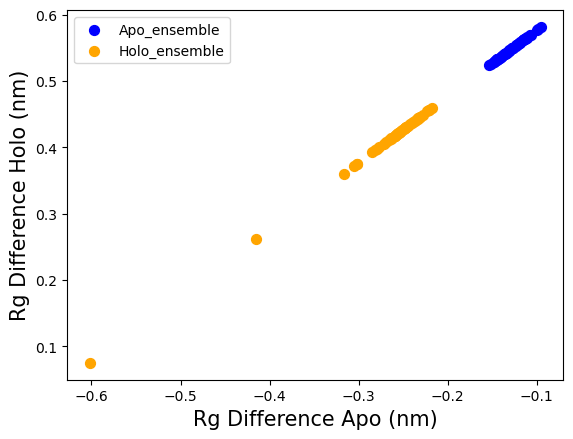

In [76]:
plt.scatter(apo_apo_rg, apo_holo_rg, color='blue', label='Apo_ensemble', marker='.', s=200)
plt.scatter(holo_apo_rg, holo_holo_rg, color='orange', label='Holo_ensemble', marker='.', s=200)
plt.xlabel('Rg Difference Apo (nm)',fontsize=15)
plt.ylabel('Rg Difference Holo (nm)',fontsize=15)
plt.legend()
plt.show()

In [92]:
jaccard_score(pair_dict['apo_ref_flatten'],pair_dict['holo_ensemble_flatten'][0])

0.6005665722379604

In [19]:
generated_pdb_df = extract_ensemble(output_path,'2RS9-13_B')

In [20]:
group_A=[]
group_B=[]
for index, content in generated_pdb_df.iterrows():
    if labels[index]==1:
        group_B.append(content['full_path'])
    else:
        group_A.append(content['full_path'])

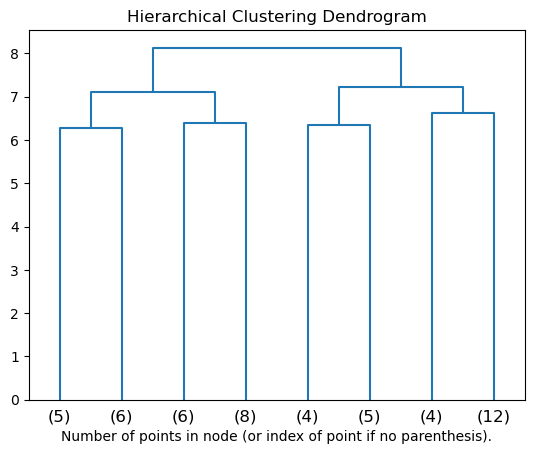

In [80]:
from scipy.cluster.hierarchy import dendrogram
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(ensemble_data)

plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=2)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

In [89]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(ensemble_data, reference_vector.reshape(1, -1))

In [90]:
similarities

array([[0.84004534],
       [0.84004534],
       [0.85729432],
       [0.8331981 ],
       [0.8331981 ],
       [0.83473395],
       [0.85321933],
       [0.83831594],
       [0.84204179],
       [0.83627832],
       [0.83627832],
       [0.83158255],
       [0.83900739],
       [0.82343903],
       [0.82638516],
       [0.83627832],
       [0.83939296],
       [0.83529497],
       [0.8325113 ],
       [0.84052048],
       [0.83831594],
       [0.84381236],
       [0.83473395],
       [0.84695506],
       [0.84381236],
       [0.82874428],
       [0.82345376],
       [0.83983877],
       [0.83983877],
       [0.83831594],
       [0.83561191],
       [0.82574744],
       [0.82713839],
       [0.84884877],
       [0.8331981 ],
       [0.84271981],
       [0.8331981 ],
       [0.84160531],
       [0.85196382],
       [0.85196382],
       [0.83167069],
       [0.84665575],
       [0.84665575],
       [0.84070439],
       [0.83158255],
       [0.85632761],
       [0.83082414],
       [0.842

# Visualize and Save the Result

In [25]:
ensemble_maps = np.array(contact_maps)
mask_A = labels == 0
mask_B = labels == 1

ensemble_maps_A = ensemble_maps[mask_A] 
ensemble_maps_B = ensemble_maps[mask_B]

average_contact_map_A = np.mean(ensemble_maps_A, axis=0) 
average_contact_map_B = np.mean(ensemble_maps_B, axis=0)
ensemble_maps = np.array(contact_maps)  # shape: (50, N, N)

# Compute average across the first axis (ensemble members)
average_contact_map = np.mean(ensemble_maps, axis=0) 

In [29]:
import shutil
dest_folder_A = os.path.join(output_path,'2RS9_group_A_selected')
dest_folder_B = os.path.join(output_path,'2RS9_group_B_selected')
# Create destination folder if it doesn't exist
os.makedirs(dest_folder_A, exist_ok=True)
os.makedirs(dest_folder_B, exist_ok=True)

# Loop through each file path in the DataFrame and copy
for src in group_A:
    print(src)
    if os.path.isfile(src):  # Check if source file exists
        shutil.copy(src, dest_folder_A)
    else:
        print(f"Missing file: {src}")

print(f"✅ Copied {len(group_A)} files to {dest_folder_A}")

# Loop through each file path in the DataFrame and copy
for src in group_B:
    print(src)
    if os.path.isfile(src):  # Check if source file exists
        shutil.copy(src, dest_folder_B)
    else:
        print(f"Missing file: {src}")
print(f"✅ Copied {len(group_B)} files to {dest_folder_B}")

/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles/2RS9-13_B/intermediate/2RS9-13_B_iter_0307.pdb
/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles/2RS9-13_B/intermediate/2RS9-13_B_iter_0450.pdb
/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles/2RS9-13_B/intermediate/2RS9-13_B_iter_0466.pdb
/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles/2RS9-13_B/intermediate/2RS9-13_B_iter_0321.pdb
/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles/2RS9-13_B/intermediate/2RS9-13_B_iter_0472.pdb
/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles/2RS9-13_B/intermediate/2RS9-13_B_iter_0384.pdb
/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles/2RS9-13_B/intermediate/2RS9-13_B_iter_0473.pdb
/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles/2RS9-13_B/intermediate/2RS9-13_B_iter_0323.pdb
/global/cfs/cdir

In [30]:
averages_A,ref_result_A, contact_maps_A,ref_contact_A,results_A, best_A= generate_rmsd_alphaSAXS('2RS9-13_B',ref_path,output_path)

In [31]:
averages_B,ref_result_B, contact_maps_B,ref_contact_B,results_B, best_B= generate_rmsd_alphaSAXS('2D9E-12_A',ref_path,output_path)

In [ ]:
def flatten_contact_map(cm):
    # Use upper triangle without diagonal
    return cm[np.triu_indices_from(cm, k=1)]
ensemble_data_A = np.array([flatten_contact_map(cm) for cm in contact_maps_A])
reference_vector_A = flatten_contact_map(ref_contact_A)
ensemble_data_A = np.array([flatten_contact_map(cm) for cm in contact_maps_B])
reference_vector_A = flatten_contact_map(ref_contact_B)

In [33]:
from sklearn.metrics import jaccard_score
jaccard_score_A_A = jaccard_score(ensemble_data_A,reference_vector_A)

NameError: name 'reference_vector_A' is not defined